In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

train_df = pd.read_csv("../../data/network_anomaly/KDDTrain+.txt", header=None, names=col_names)
test_df = pd.read_csv("../../data/network_anomaly/KDDTest+.txt", header=None, names=col_names)

train_df = train_df.drop(columns=["difficulty"])
test_df = test_df.drop(columns=["difficulty"])

print("NSL-KDD NETWORK INTRUSION DETECTION DATASET")
print()
print(f"Train shape  : {train_df.shape}")
print(f"Test shape   : {test_df.shape}")
print()
print("Sample labels:", train_df["label"].value_counts().head(10).to_dict())

NSL-KDD NETWORK INTRUSION DETECTION DATASET

Train shape  : (125973, 42)
Test shape   : (22544, 42)

Sample labels: {'normal': 67343, 'neptune': 41214, 'satan': 3633, 'ipsweep': 3599, 'portsweep': 2931, 'smurf': 2646, 'nmap': 1493, 'back': 956, 'teardrop': 892, 'warezclient': 890}


ATTACK CATEGORY ANALYSIS

Train — Attack category distribution:
  normal      :  67,343 (53.46%)
  dos         :  45,927 (36.46%)
  probe       :  11,656 (9.25%)
  r2l         :     995 (0.79%)
  u2r         :      52 (0.04%)

Total attacks  : 58,630 (46.54%)
Total normal   : 67,343 (53.46%)


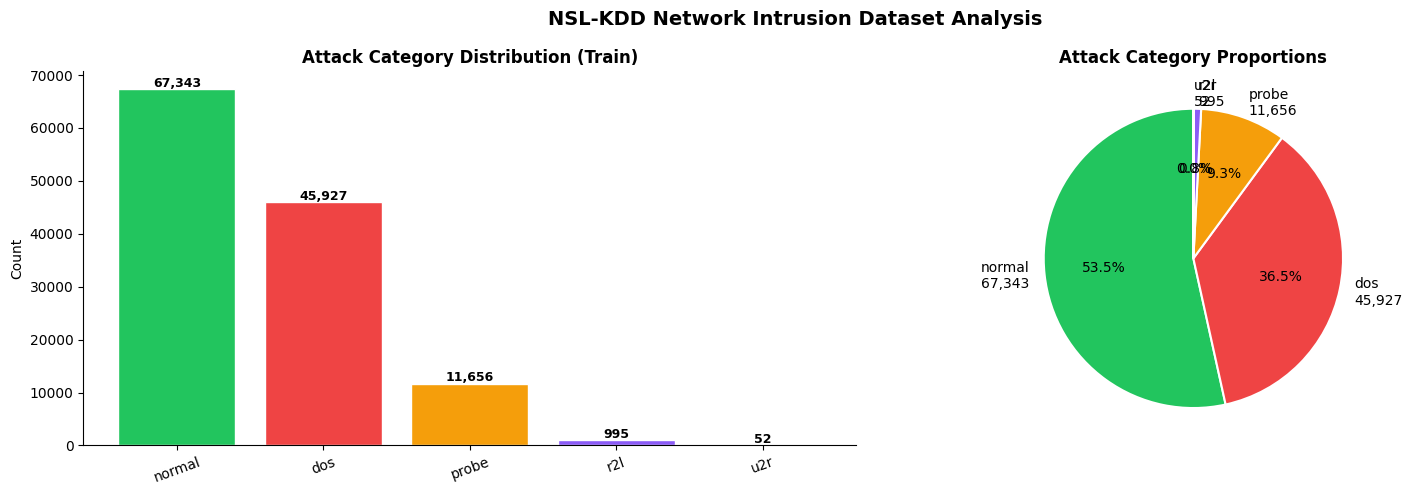

In [2]:
# Understanding Attack Categories
print("ATTACK CATEGORY ANALYSIS")
print()

ATTACK_MAP = {
    "normal": "normal",
    "neptune": "dos", "back": "dos", "land": "dos", "pod": "dos",
    "smurf": "dos", "teardrop": "dos", "apache2": "dos", "udpstorm": "dos",
    "processtable": "dos", "worm": "dos",
    "ipsweep": "probe", "nmap": "probe", "portsweep": "probe", "satan": "probe",
    "mscan": "probe", "saint": "probe",
    "ftp_write": "r2l", "guess_passwd": "r2l", "httptunnel": "r2l", "imap": "r2l",
    "multihop": "r2l", "named": "r2l", "phf": "r2l", "sendmail": "r2l",
    "snmpgetattack": "r2l", "snmpguess": "r2l", "spy": "r2l", "warezclient": "r2l",
    "warezmaster": "r2l", "xlock": "r2l", "xsnoop": "r2l",
    "buffer_overflow": "u2r", "loadmodule": "u2r", "perl": "u2r", "ps": "u2r",
    "rootkit": "u2r", "sqlattack": "u2r", "xterm": "u2r"
}

train_df["attack_category"] = train_df["label"].map(ATTACK_MAP).fillna("unknown")
test_df["attack_category"] = test_df["label"].map(ATTACK_MAP).fillna("unknown")

train_df["is_attack"] = (train_df["attack_category"] != "normal").astype(int)
test_df["is_attack"] = (test_df["attack_category"] != "normal").astype(int)

print("Train — Attack category distribution:")
cat_dist = train_df["attack_category"].value_counts()
for cat, count in cat_dist.items():
    pct = count / len(train_df) * 100
    print(f"  {cat:<12}: {count:>7,} ({pct:.2f}%)")

print()
print(f"Total attacks  : {train_df['is_attack'].sum():,} ({train_df['is_attack'].mean()*100:.2f}%)")
print(f"Total normal   : {(train_df['is_attack']==0).sum():,} ({(train_df['is_attack']==0).mean()*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {"normal": "#22c55e", "dos": "#ef4444", "probe": "#f59e0b", "r2l": "#8b5cf6", "u2r": "#ec4899", "unknown": "#6b7785"}
cat_counts = train_df["attack_category"].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values,
            color=[colors.get(c, "#6b7785") for c in cat_counts.index], edgecolor="white")
axes[0].set_title("Attack Category Distribution (Train)", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)
for i, (cat, val) in enumerate(cat_counts.items()):
    axes[0].text(i, val + 500, f"{val:,}", ha="center", fontsize=9, fontweight="bold")

axes[1].pie(cat_counts.values,
            labels=[f"{c}\n{v:,}" for c, v in cat_counts.items()],
            colors=[colors.get(c, "#6b7785") for c in cat_counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Attack Category Proportions", fontweight="bold")

plt.suptitle("NSL-KDD Network Intrusion Dataset Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/network_anomaly/attack_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

FEATURE ANALYSIS

Numeric features   : 38
Categorical features: 3

Top features correlated with attack (numeric):
  same_srv_rate                      : 0.7519
  dst_host_srv_count                 : 0.7225
  dst_host_same_srv_rate             : 0.6938
  logged_in                          : 0.6902
  dst_host_srv_serror_rate           : 0.6550
  dst_host_serror_rate               : 0.6518
  serror_rate                        : 0.6507
  srv_serror_rate                    : 0.6483
  count                              : 0.5764
  dst_host_count                     : 0.3751
  srv_rerror_rate                    : 0.2535
  dst_host_srv_rerror_rate           : 0.2534

Attack rate by protocol_type:
protocol_type
icmp   84.2100
tcp    47.8000
udp    17.0700
Name: is_attack, dtype: float64

Attack rate by flag:
         mean  count  attack_rate_%
flag                               
RSTOS0 1.0000    103       100.0000
SH     0.9926    271        99.2620
S0     0.9898  34851        98.9842
RSTR   0.9

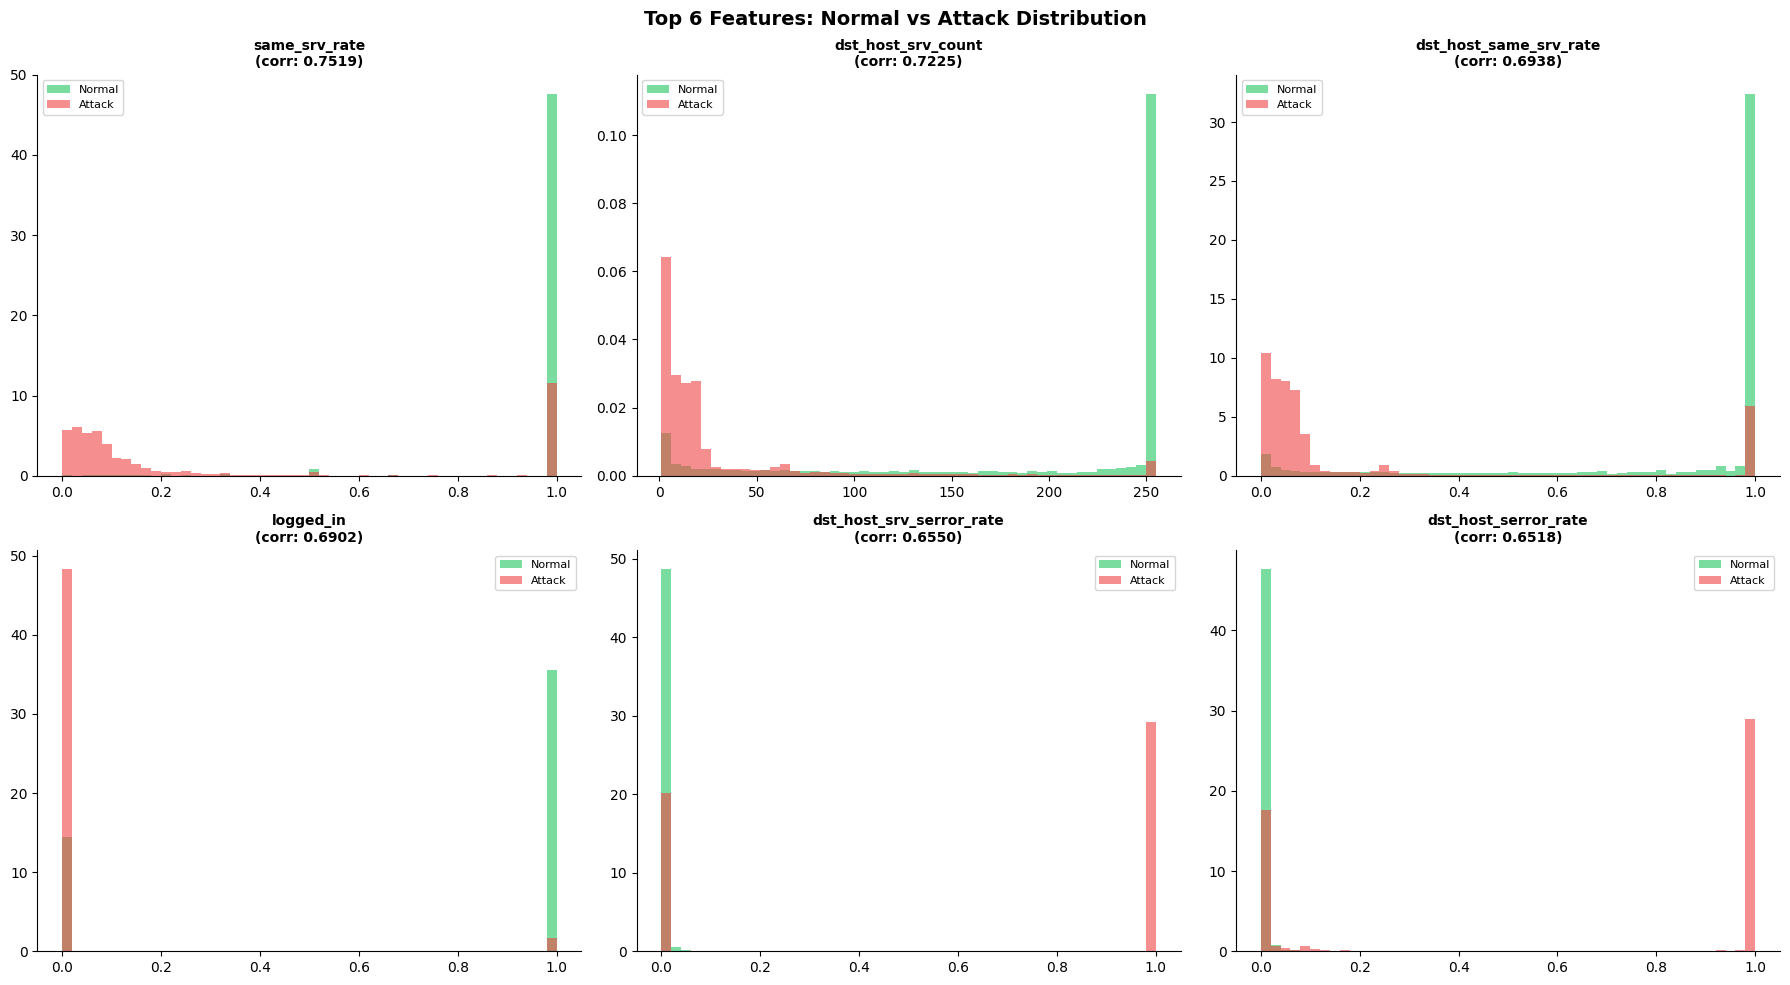

In [3]:
# Feature Analysis
print("FEATURE ANALYSIS")
print()

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["is_attack", "label", "attack_category"]]
categorical_cols = ["protocol_type", "service", "flag"]

print(f"Numeric features   : {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print()

print("Top features correlated with attack (numeric):")
correlations = train_df[numeric_cols + ["is_attack"]].corr()["is_attack"].drop("is_attack").abs()
correlations = correlations.sort_values(ascending=False)
for feat, corr in correlations.head(12).items():
    print(f"  {feat:<35}: {corr:.4f}")

print()
print("Attack rate by protocol_type:")
print(train_df.groupby("protocol_type")["is_attack"].mean().round(4) * 100)

print()
print("Attack rate by flag:")
flag_attack = train_df.groupby("flag")["is_attack"].agg(["mean", "count"])
flag_attack["attack_rate_%"] = flag_attack["mean"] * 100
print(flag_attack.sort_values("attack_rate_%", ascending=False).head(8))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

top_features = correlations.head(6).index.tolist()
for i, feat in enumerate(top_features):
    normal_vals = train_df[train_df["is_attack"] == 0][feat].clip(
        train_df[feat].quantile(0.01), train_df[feat].quantile(0.99))
    attack_vals = train_df[train_df["is_attack"] == 1][feat].clip(
        train_df[feat].quantile(0.01), train_df[feat].quantile(0.99))
    axes[i].hist(normal_vals, bins=50, color="#22c55e", alpha=0.6, label="Normal", density=True)
    axes[i].hist(attack_vals, bins=50, color="#ef4444", alpha=0.6, label="Attack", density=True)
    axes[i].set_title(f"{feat}\n(corr: {correlations[feat]:.4f})", fontweight="bold", fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle("Top 6 Features: Normal vs Attack Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/network_anomaly/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

DATA QUALITY REPORT

Missing values (train): 0
Missing values (test) : 0

Zero-variance features:
  ['num_outbound_cmds']
  Will be dropped: 1 features

Service distribution (top 10):
service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64

Attack types in test not seen in train:
  {'named', 'udpstorm', 'mailbomb', 'snmpgetattack', 'worm', 'sendmail', 'ps', 'httptunnel', 'snmpguess', 'sqlattack', 'saint', 'xlock', 'apache2', 'xterm', 'mscan', 'xsnoop', 'processtable'}
  Count: 17 new attack types in test set

This is why NSL-KDD is challenging — test has unseen attack patterns


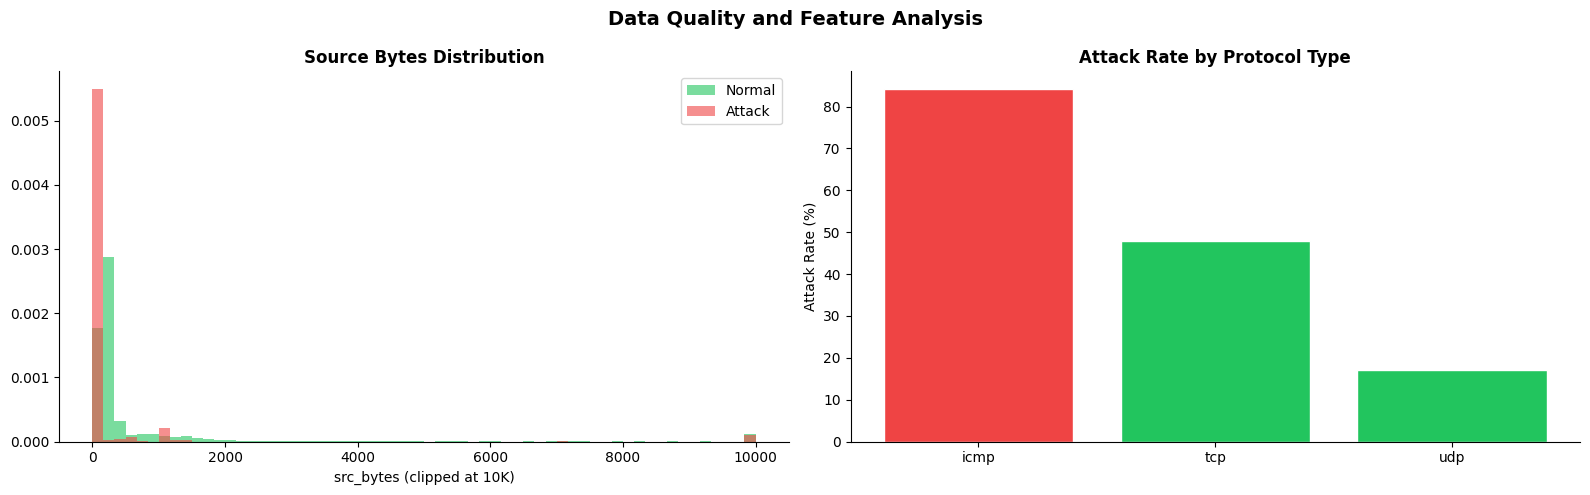

In [4]:
# Missing Values and Data Quality
print("DATA QUALITY REPORT")
print()

print("Missing values (train):", train_df.isnull().sum().sum())
print("Missing values (test) :", test_df.isnull().sum().sum())
print()

print("Zero-variance features:")
low_var = [c for c in numeric_cols if train_df[c].std() < 0.001]
print(f"  {low_var}")
print(f"  Will be dropped: {len(low_var)} features")
print()

print("Service distribution (top 10):")
print(train_df["service"].value_counts().head(10))
print()

print("Attack types in test not seen in train:")
train_attacks = set(train_df["label"].unique())
test_attacks = set(test_df["label"].unique())
new_attacks = test_attacks - train_attacks
print(f"  {new_attacks}")
print(f"  Count: {len(new_attacks)} new attack types in test set")
print()
print("This is why NSL-KDD is challenging — test has unseen attack patterns")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

src_bytes_normal = train_df[train_df["is_attack"]==0]["src_bytes"].clip(0, 10000)
src_bytes_attack = train_df[train_df["is_attack"]==1]["src_bytes"].clip(0, 10000)
axes[0].hist(src_bytes_normal, bins=60, color="#22c55e", alpha=0.6, label="Normal", density=True)
axes[0].hist(src_bytes_attack, bins=60, color="#ef4444", alpha=0.6, label="Attack", density=True)
axes[0].set_title("Source Bytes Distribution", fontweight="bold")
axes[0].set_xlabel("src_bytes (clipped at 10K)")
axes[0].legend()

proto_attack = train_df.groupby("protocol_type")["is_attack"].mean() * 100
axes[1].bar(proto_attack.index, proto_attack.values,
            color=["#22c55e" if v < 50 else "#ef4444" for v in proto_attack.values],
            edgecolor="white")
axes[1].set_title("Attack Rate by Protocol Type", fontweight="bold")
axes[1].set_ylabel("Attack Rate (%)")

plt.suptitle("Data Quality and Feature Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../../notebooks/network_anomaly/data_quality.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Save Cleaned Data and Key Findings
import json
import os

print("KEY FINDINGS")
print()
print(f"1. Dataset size     : {len(train_df):,} train | {len(test_df):,} test")
print(f"2. Attack rate      : {train_df['is_attack'].mean()*100:.2f}% of traffic is attacks")
print(f"3. Attack types     : 4 categories — DoS, Probe, R2L, U2R")
print(f"4. Best signal      : {correlations.index[0]} (corr={correlations.iloc[0]:.4f})")
print(f"5. New attacks      : {len(new_attacks)} unseen attack types in test — generalization challenge")
print(f"6. Low variance     : {len(low_var)} features to drop")
print()
print("Strategy:")
print("  Binary classification: normal vs attack")
print("  Also multiclass: normal vs dos vs probe vs r2l vs u2r")
print("  Use XGBoost + LightGBM + RandomForest")
print("  Encode categorical features (protocol, service, flag)")

os.makedirs("../../data/network_anomaly", exist_ok=True)
train_df.to_csv("../../data/network_anomaly/train_cleaned.csv", index=False)
test_df.to_csv("../../data/network_anomaly/test_cleaned.csv", index=False)

meta = {
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "low_var_features": low_var,
    "top_features": correlations.head(10).index.tolist(),
    "attack_map": ATTACK_MAP,
    "n_train": len(train_df),
    "n_test": len(test_df),
    "attack_rate_train": float(train_df["is_attack"].mean())
}

with open("../../data/network_anomaly/meta.json", "w") as f:
    json.dump(meta, f, indent=4)

print()


KEY FINDINGS

1. Dataset size     : 125,973 train | 22,544 test
2. Attack rate      : 46.54% of traffic is attacks
3. Attack types     : 4 categories — DoS, Probe, R2L, U2R
4. Best signal      : same_srv_rate (corr=0.7519)
5. New attacks      : 17 unseen attack types in test — generalization challenge
6. Low variance     : 1 features to drop

Strategy:
  Binary classification: normal vs attack
  Also multiclass: normal vs dos vs probe vs r2l vs u2r
  Use XGBoost + LightGBM + RandomForest
  Encode categorical features (protocol, service, flag)

